In [1]:
import numpy as np
import pandas as pd
import os
import pickle
from scipy.stats import gamma
import matplotlib.pyplot as plt

# Define functions

In [2]:
#  load the data. The data is saved under the data/processed/adult48k folder
def load_cf(classifier, dataset, load_test=True, cf_method='ils_latent'):
    result_folder_path = os.path.join("counterfactuals",
                        classifier,
                        dataset)
    results = os.listdir(result_folder_path)
    # remove the ones that are not npz
    results = [r for r in results if (r.endswith(".npz")) and (cf_method in r)]
    
    def select_test (x):return "test" in x if load_test else ("test" not in x)
    # remove those that contains "test" in the name
    results = [r for r in results if select_test(r)]
    
    # take the most recent using os.path.getmtime
    results = sorted(results,key=lambda x: os.path.getmtime(os.path.join(result_folder_path,x)),reverse=True)
    print("I found",len(results),"files")
    if len(results) > 1:
        for i,f in enumerate(results):
            print(str(i)+")",f)
        # i = input()
        # take the most recent 
        i = 0
        if isinstance(i,int):
            results = [results[i]]
        else:
            results = [results[-1]]
    print("for model",classifier,"using file",results[-1])

    r = results[-1]
    
    print("checking",r)
    
    # load the counterfactuals most recent using nupy
    cfs = np.load(os.path.join(result_folder_path, r),allow_pickle=True)
    return cfs


In [47]:
import src.cf_generator_ils as cfils
import importlib
import src.utils as utl
importlib.reload(utl)
from src.data_processor import DataProcessor
from src.model_trainer import ModelTrainer
config = utl.load_config('config.yaml')
data_processor = DataProcessor(config=config)
dt_name = 'adult48k'  # or 'german_credit'
splits = data_processor.load_splits(dt_name)

cf_generator = cfils.IlsCFGenerator(config=config,
                                    dataset_name=dt_name,
                                    )
reference_set = splits['X_train'].copy()
feat_names = splits['X_train'].columns.to_list()
target_name = data_processor.target_name
# we add the target variable to the reference set
reference_set[target_name] = splits['y_train']
cf_generator.setup(
    reference_data=reference_set,
    #feature_names=feat_names,
    continuous_features = feat_names,
    categorical_features=[],#data_processor.categorical_features,
    target_name=target_name,
    )

X_calibration=splits['X_calibration'][:].copy()
y_calibration=splits['y_calibration'][:].copy()

model_trainer = ModelTrainer(config)
models = model_trainer.train_model(X_train=splits['X_train'], 
                                    y_train=splits['y_train'], 
                                    X_test=splits['X_test'], 
                                    y_test=splits['y_test'],
                                    dataset_name=dt_name)
for model_name, model in models.items():
    cf_generator._setup_model_components(model, model_name, X_calibration, y_calibration)
    latent = cf_generator._explainers[model_name]


Loaded feature names from data/processed/adult48k/feature_names.csv
Loaded X_train from data/processed/adult48k/X_train.npz
Loaded y_train from data/processed/adult48k/y_train.npz
Loaded X_test from data/processed/adult48k/X_test.npz
Loaded y_test from data/processed/adult48k/y_test.npz
Loaded X_calibration from data/processed/adult48k/X_calibration.npz
Loaded y_calibration from data/processed/adult48k/y_calibration.npz
Processing random_forest for adult48k
Loaded random_forest model from models/adult48k/random_forest.pkl
Loaded existing random_forest model
Processing mlp for adult48k
Loaded mlp model from models/adult48k/mlp.pkl
Loaded existing mlp model
Processing xgboost for adult48k
Loaded xgboost model from models/adult48k/xgboost.pkl
Loaded existing xgboost model
Processing lgbm for adult48k
Loaded lgbm model from models/adult48k/lgbm.pkl
Loaded existing lgbm model
trying to load explainer model from counterfactuals/cf_generators/ils/ils_explainer_adult48k_random_forest.pkl
Loade

In [ ]:
# latent = cf_generator._explainers['random_forest']
# x_input = cfs_[0]["original_instance"].values
# _,original_instance_transformed = latent.transform(x_input)
# latent_cfs = cfs_[0]["latent_counterfactuals"].values
# input_cfs = cfs_[0]["counterfactuals"].values
# #distancies
# # = get_distances(latent_cfs, original_instance_transformed,policy=metric)

In [ ]:
from sklearn.metrics.pairwise import cosine_distances

def compute_distance(x1, x2, distance_name="l2"):
    
    d = np.inf
    
    if distance_name == "l2":
        d = np.linalg.norm(x1 - x2, ord=None,axis=1)[0]
        
    elif distance_name == "cosine":
        d = cosine_distances(x1.reshape(1, -1), x2.reshape(1, -1))[0][0]

    return d

In [186]:
def compute_distances(cfs_, bb, cf_method, 
                        compute_cf_target=False, 
                        compute_rejection=False, 
                        tau=None, 
                        distance="l2",
                        aggr='min'):
    # I compute the distance between the original instance and all of its counterfactuals
    # then I select the counterfactual at min distance

    # cf_key = 'latent_counterfactuals' if cf_method == 'ils_latent' else 'counterfactuals'
    # cf_key_bb = 'counterfactuals'

    
    dist_dict = {}
    # this is a dict having:
        ### key = index of the row in the calibration set (0-300)
        ### value = [index of the counterfactual corresponding to the one at minimal distance, minimal distance]

    for i in range(len(cfs_)):

        xi = cfs_[i]

        # only keep correct counterfactuals
        x_input = xi["original_instance"].values
        bb_pred = bb.predict(x_input)
        x_cf = xi['counterfactuals'].copy()
        
        if cf_method == 'ils_latent':
            x_cf_latent = xi['latent_counterfactuals'].copy()
            n_features_latent = x_cf_latent.shape[1] 
            # 
            _, x_input_latent = latent.transform(x_input)

        if x_cf.shape[0] == 0:
            print("No counterfactuals found for instance", i)
            dist_dict[i] = {
                'best_cf': [], 
                'min_d': np.inf, 
                'bb_is_correct': is_correct
            }
            continue
        else:
            if compute_cf_target:
                cf_preds = bb.predict(x_cf.values)
                x_cf['target'] = cf_preds
                if cf_method == 'ils_latent':
                    x_cf_latent['target'] = cf_preds
                
            n_features = x_cf.shape[1]-1
            CF_input = x_cf[x_cf['target'] != bb_pred[0]].values[:,:n_features]
            if cf_method == 'ils_latent':
                CF_latent = x_cf_latent[x_cf_latent['target'] != bb_pred[0]].values[:,:n_features_latent]

            if CF_input.shape[0] == 0:
                print("No CORRECT counterfactuals found for instance", i)
                dist_dict[i] = {
                    'best_cf': [], 
                    'min_d': np.inf, 
                    'bb_is_correct': False,
                    'accept': 1 if compute_rejection else None
                }
                continue
            else:
                # check if the black box prediction is correct
                if bb_pred[0] != xi['true_class'][0]:
                    is_correct = False
                else:
                    is_correct = True
    
                # compute the L2 distance between the original instance and all of its counterfactuals
                # and select the one at minimal distance
                l2_dist_dict = {}
                CF = CF_latent if cf_method == 'ils_latent' else CF_input
                x = x_input_latent if cf_method == 'ils_latent' else x_input

                for j in range(CF.shape[0]):
                    d = compute_distance(CF[j,:], x, distance_name=distance)
                    #d = np.linalg.norm(CF[j,:] - x_input, ord=None,axis=1)[0]
                    l2_dist_dict[j] = d
                if aggr == 'min':
                    # take the minimum distance
                    aggr_over_all_cfs = np.min(list(l2_dist_dict.values()))
                elif aggr == 'mean':
                    # take the mean distance
                    aggr_over_all_cfs = np.mean(list(l2_dist_dict.values()))
                elif aggr == 'max':
                    # take the maximum distance
                    aggr_over_all_cfs = np.max(list(l2_dist_dict.values()))

                best_cfs = [k for k, v in l2_dist_dict.items() if v == aggr_over_all_cfs]

                dist_dict[i] = {
                    'best_cf': best_cfs, # index: this should be the same for both input and latent cfs
                    'min_d': aggr_over_all_cfs, 
                    'bb_is_correct': is_correct
                }
        
                if compute_rejection:
                    # compute the rejection rate
                    if tau is not None:
                        dist_dict[i]['tau'] = tau
                        if aggr_over_all_cfs >= tau:
                            dist_dict[i]['accept'] = 1
                        else:
                            dist_dict[i]['accept'] = 0
                    else:
                        print("Please provide the rejection threshold tau")
                
    return dist_dict

In [187]:
# find tau 
def assign_reject_by_threshold(cal_dist_dict, C):
    """
    Assigns 'reject' flag to each key in val_dict based on threshold tau.
    Args:
        val_dict (dict): {key: value}
        C (float): Target coverage, i.e, the fraction of values to be above tau (0 < C < 1)
    Returns:
        tau (float): The threshold value
        new_dict (dict): Updated dict with 'accept' field
    """
    if not 0 < C < 1:
        raise ValueError("C must be in (0,1)")
    
    all_distances = [cal_dist_dict[i]['min_d'] for i in range(len(cal_dist_dict))]
    values = np.array(all_distances)
    n = len(values)
    k = int(np.ceil(C * n))
    sorted_values = np.sort(values)
    
    if k == 0:
        tau = sorted_values.max() + 1e-8
    else:
        tau = sorted_values[-k]

    for key, value in cal_dist_dict.items():
        accept = 1 if value['min_d'] >= tau else 0
        cal_dist_dict[key]['accept'] = accept
        cal_dist_dict[key]['tau'] = tau  # add tau to the dict

    return tau, cal_dist_dict

In [7]:
def fit_tau(data, X_cal, cal_dist_dict, metric, n_samples, max_rej_fraction):
    
    # distance between test examples and counterfactuals
    dist_list = [i[1] for i in cal_dist_dict.values()]

    # fit gamma distribution and sample data
    alpha, loc, beta = gamma.fit([d for d in dist_list if d != np.inf])
    candidate_tau = gamma.rvs(alpha, loc, beta, size = n_samples)

    #miscl_by_r = misprediction_rate(data)
    
    m_max = 0
    tau = np.inf
    n_rej_final = 0 
    
    for t in candidate_tau:
        # check number of instances that will be rejected, i.e., all those with distance < t
        rej = [x for x, d in cal_dist_dict.items() if d[1] < t]
        n_rej = len(rej)
        rej_rate = n_rej / X_cal.shape[0]
        
        # constraints: 1) rejection rate below thr
        if rej_rate < max_rej_fraction:
            m = data[metric][n_rej] 
            if m > m_max:
                m_max = m
                n_rej_final = n_rej
                tau = t
            elif (m == m_max) & (t < tau):
                n_rej_final = n_rej
                tau = t

    base = data[metric][0]
    frac_rejected = n_rej_final / n
    
    return base, tau, m_max, frac_rejected, n_rej_final

In [ ]:
means = np.array([38.643585, 1079.0676, 87.50231, 40.422382], dtype=np.float32)
stds = np.array([13.71037, 7451.9424, 403.00046, 12.391317], dtype=np.float32)

target_encoding_mappings = {
    'P(t=1|workclass)': {' ?': 0.09467667023937121, ' Federal-gov': 0.39175977653631283, ' Local-gov': 0.2955994897959184, ' Never-worked': 0.17492898751993913, ' Private': 0.21786704418097091, ' Self-emp-inc': 0.5533923303834808, ' Self-emp-not-inc': 0.27887105126877265, ' State-gov': 0.2675416456335184, ' Without-pay': 0.16366183661631867},
    'P(t=1|education)': {' Preschool': 0.01246469803593554, 'Associates': 0.2553249590387766, 'Bachelors': 0.41283489096573206, 'High School': 0.17125496961968345, 'Less than High School': 0.057707509881422925, 'Masters': 0.5491155438464433, 'PhD': 0.7338935574229691},
    'P(t=1|marital-status)': {' Divorced': 0.1011608623548922, ' Married-AF-spouse': 0.3568927832277808, ' Married-civ-spouse': 0.4461325349658162, ' Married-spouse-absent': 0.09235668789808917, ' Never-married': 0.045479928026307626, ' Separated': 0.06470588235294118, ' Widowed': 0.08432147562582346},
    'P(t=1|occupation)': {' ?': 0.09433962264150944, ' Adm-clerical': 0.1368739975049011, ' Armed-Forces': 0.2747900574417321, ' Craft-repair': 0.2262761780104712, ' Exec-managerial': 0.47781794281958595, ' Farming-fishing': 0.11610738255033556, ' Handlers-cleaners': 0.06660231660231661, ' Machine-op-inspct': 0.12309728656518862, ' Other-service': 0.04143814747105423, ' Priv-house-serv': 0.012396694266692597, ' Prof-specialty': 0.4510693454309786, ' Protective-serv': 0.3133265513733469, ' Sales': 0.2679869186046512, ' Tech-support': 0.29045643153526973, ' Transport-moving': 0.20424628450106158},
    'P(t=1|relationship)': {' Husband': 0.4486711300466626, ' Not-in-family': 0.101406659779067, ' Other-relative': 0.034528552456839307, ' Own-child': 0.014641867827463396, ' Unmarried': 0.060292682926829266, ' Wife': 0.4688974688974689},
    'P(t=1|race)': {' Amer-Indian-Eskimo': 0.11702127659574468, ' Asian-Pac-Islander': 0.26925608953258723, ' Black': 0.1208110992529349, ' Other': 0.12315270935960591, ' White': 0.2539868780230832},
    'P(t=1|sex)': {' Female': 0.10925148221343874, ' Male': 0.3037672281776417},
    'P(t=1|native-country)': {' ?': 0.25670945157526254, ' Cambodia': 0.29596096535683447, ' Canada': 0.3461538363070802, ' China': 0.2950798931789342, ' Columbia': 0.047347385199526214, ' Cuba': 0.24637675834941963, ' Dominican-Republic': 0.04859107916476352, ' Ecuador': 0.1413703885882764, ' El-Salvador': 0.07096797268680777, ' England': 0.370075791414291, ' France': 0.39526824068520733, ' Germany': 0.2815533977049296, ' Greece': 0.36066788369302705, ' Guatemala': 0.03431919131249288, ' Haiti': 0.12048549321336761, ' Holand-Netherlands': 0.20814918021620007, ' Honduras': 0.1696408828467303, ' Hong': 0.25930173247485605, ' Hungary': 0.27562451930735055, ' India': 0.41059567611361025, ' Iran': 0.3702306992159193, ' Ireland': 0.28833591282914844, ' Italy': 0.3237923285831285, ' Jamaica': 0.14152743110161864, ' Japan': 0.34774510976311024, ' Laos': 0.15177966918238522, ' Mexico': 0.04942166140904311, ' Nicaragua': 0.07051081116601206, ' Outlying-US(Guam-USVI-etc)': 0.1268039075818783, ' Peru': 0.09748804848454774, ' Philippines': 0.2881355932202833, ' Poland': 0.19545624420661376, ' Portugal': 0.17964687348153752, ' Puerto-Rico': 0.10869566202462137, ' Scotland': 0.18866084554388723, ' South': 0.17391793608051587, ' Taiwan': 0.39823419797998383, ' Thailand': 0.18619587461185555, ' Trinadad&Tobago': 0.1288920062852573, ' United-States': 0.24397700310275597, ' Vietnam': 0.08160984068441025, ' Yugoslavia': 0.3016342387854267}
}


def make_sample_human_readable(sample):
    """
    Convert a preprocessed sample back to human-readable format.
    
    Parameters:
    - sample: array-like, the preprocessed sample values
    - means: array, means used for numeric feature normalization
    - stds: array, standard deviations used for numeric feature normalization  
    - target_encoding_mappings: dict, mappings from category to target-encoded value
    
    Returns:
    - dict: human-readable interpretation of the sample
    """
    
    if isinstance(sample, pd.Series):
        sample = sample.values
    
    readable_sample = {}
    
    # First 4 features are numeric: age, capital-gain, capital-loss, hours-per-week
    numeric_feature_names = ['age', 'capital-gain', 'capital-loss', 'hours-per-week']
    
    # Denormalize numeric features
    numeric_values = sample[:4]
    denormalized = (numeric_values * stds) + means
    
    for i, name in enumerate(numeric_feature_names):
        if name == 'age':
            readable_sample[name] = f"{int(round(denormalized[i]))} years old"
            readable_sample['age_raw'] = sample[i]
        elif name == 'capital-gain':
            readable_sample['capital-gain'] = f"${int(round(denormalized[i]))}"
            readable_sample['capital-gain_raw'] = sample[i]
        elif name == 'capital-loss':
            readable_sample['capital-loss'] = f"${int(round(denormalized[i]))}"
            readable_sample['capital-loss_raw'] = sample[i]
        elif name == 'hours-per-week':
            readable_sample['hours-per-week'] = f"{int(round(denormalized[i]))} hours/week"
            readable_sample['hours-per-week_raw'] = sample[i]
    
    # Categorical features start from index 4
    categorical_values = sample[4:]
    
    # Map target-encoded values back to original categories
    categorical_features = [
        'workclass', 'education', 'marital-status', 'occupation', 
        'relationship', 'race', 'sex', 'native-country'
    ]
    
    for i, feature_name in enumerate(categorical_features):
        if i < len(categorical_values):
            encoded_value = categorical_values[i]
            mapping_key = f"P(t=1|{feature_name})"
            
            if mapping_key in target_encoding_mappings:
                category_mapping = target_encoding_mappings[mapping_key]
                
                # Find the category with the closest target-encoded value
                closest_category = min(category_mapping.keys(), 
                                        key=lambda x: abs(category_mapping[x] - encoded_value))
                
                # Apply the transformations that were done in preprocessing
                if feature_name == 'workclass':
                    # Map back to employment-type categories
                    if closest_category in [' State-gov', ' Federal-gov', ' Local-gov']:
                        employment_type = 'Government'
                    elif closest_category in [' Self-emp-not-inc', ' Self-emp-inc']:
                        employment_type = 'Self-Employed'
                    elif closest_category == ' Private':
                        employment_type = 'Privately-Employed'
                    else:
                        employment_type = closest_category.strip()
                    
                    readable_sample['workclass'] = closest_category.strip()
                    readable_sample['employment-type'] = employment_type
                
                elif feature_name == 'education':
                    # Education was already mapped in preprocessing
                    readable_sample['education'] = closest_category
                
                elif feature_name == 'occupation':
                    # Armed-Forces was mapped to Protective-serv in preprocessing
                    if closest_category == ' Armed-Forces':
                        readable_sample['occupation'] = 'Protective-serv (originally Armed-Forces)'
                    else:
                        readable_sample['occupation'] = closest_category.strip()
                
                else:
                    # For other categorical features, just clean up the category name
                    readable_sample[feature_name] = closest_category.strip()
                
                # Also show the confidence/probability for context
                probability = category_mapping[closest_category]
                readable_sample[f'{feature_name}_probability'] = f"{probability:.3f}"
            else:
                readable_sample[feature_name] = f"Unknown (encoded: {encoded_value:.3f})"
    
    return readable_sample

# Load data

In [144]:
dataset = 'adult48k'  # or 'german_credit'
classifier = 'random_forest' 
cf_method = 'lore' #'ils_latent'
aggr_function = 'min'  # 'min', 'mean', 'max'
distance = 'l2'  # cosine

# adult - ils_latent:
# - l'original distance non ha il target
# - key diverse per counterfactuals e latent_counterfactuals (n_features minori)

In [145]:
# load the counterfactuals
print('Calibration dataset')
cfs_ = load_cf(classifier, dataset,load_test=False, cf_method=cf_method)
cfs_ = cfs_['cfs']

print('Test dataset')
cfs_test = load_cf(classifier, dataset, load_test=True, cf_method=cf_method)
cfs_test = cfs_test['cfs']

# load the RF model
with open('models/'+dataset+'/'+classifier+'.pkl', 'rb') as f:
    rf = pickle.load(f)

Calibration dataset
I found 1 files
for model random_forest using file cf_results_lore_genetic_calibration_20250307_032735.npz
checking cf_results_lore_genetic_calibration_20250307_032735.npz
Test dataset
I found 1 files
for model random_forest using file cf_results_lore_genetic_test_20250307_051140.npz
checking cf_results_lore_genetic_test_20250307_051140.npz


In [22]:
# print(rf.predict(x200['original_instance']))
# print(x200['true_class'])
# print(rf.predict(x200['counterfactuals'].iloc[0][:12].values.reshape(1,-1)))
# print(x200['counterfactuals'].iloc[0]['target'])

# Rejection policy

x=2.5 is at percentile 0.996
percentile 0.95 is x=0.298


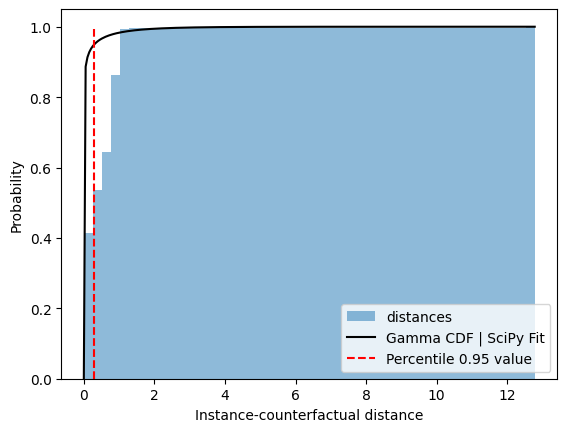

In [ ]:
# all_distances = [cal_dist_dict[i]['min_d'] for i in range(len(cfs_))]

# plt.hist(all_distances, bins=50, density=True, cumulative=True, alpha=0.5, label='distances')
# param = gamma.fit(all_distances)
# x = np.linspace(0, np.max(all_distances), 250)
# scicdf = gamma.cdf(x, *param)

# plt.plot(x, scicdf, 'k', label='Gamma CDF | SciPy Fit')

# # Calculate the percentile
# value = 2.50
# pct = gamma.cdf(value, *param)
# print(f'x={value} is at percentile {pct:.3f}')

# # Calculate the value
# pct = 0.95
# val = gamma.ppf(pct, *param)
# print(f'percentile {pct} is x={val:.3f}')

# plt.vlines(val, 0, 1, color='r', linestyle='--', label=f'Percentile {pct} value')

# plt.xlabel('Instance-counterfactual distance')
# plt.ylabel('Probability')
# plt.legend()
# plt.show()

### Calibration: distance + tau

In [188]:
# load the RF model
# with open('models/german_credit/random_forest.pkl', 'rb') as f:
#     rf = pickle.load(f)
    
# set compute_cf_target=False for adult (lore)
cal_dist_dict = compute_distances(cfs_, rf, cf_method, 
                                    compute_cf_target=False, 
                                    compute_rejection=False, 
                                    distance=distance,
                                    aggr=aggr_function)
tau, cal_dist_dict = assign_reject_by_threshold(cal_dist_dict, 0.75)
tau

0.15013718906714849

In [189]:
len([i for i in cal_dist_dict if len(cal_dist_dict[i]['best_cf'])==0])/ len(cal_dist_dict) # numeber of instances without counterfactual

0.0

In [153]:
len([i for i in cal_dist_dict if cal_dist_dict[i]['accept']==0])/(len(cal_dist_dict))  # this is the acceptance rate

0.25

### Test: distance + rejection policy

In [190]:
test_dist_dict = compute_distances(cfs_test, rf, cf_method, 
                                    compute_cf_target=False, 
                                    compute_rejection=True, 
                                    tau=tau, distance=distance, aggr=aggr_function)
#tau, cal_dist_dict = assign_reject_by_threshold(cal_dist_dict, 0.75)
tau

0.15013718906714849

In [191]:
len([i for i in test_dist_dict if len(test_dist_dict[i]['best_cf'])==0])/ len(test_dist_dict)

0.0

In [192]:
len([i for i in test_dist_dict if test_dist_dict[i]['accept']==1])/(len(test_dist_dict))  # this is the acceptance rate

0.756

# Visualizations

## Plot the accept/reject decision surface of the calibration set

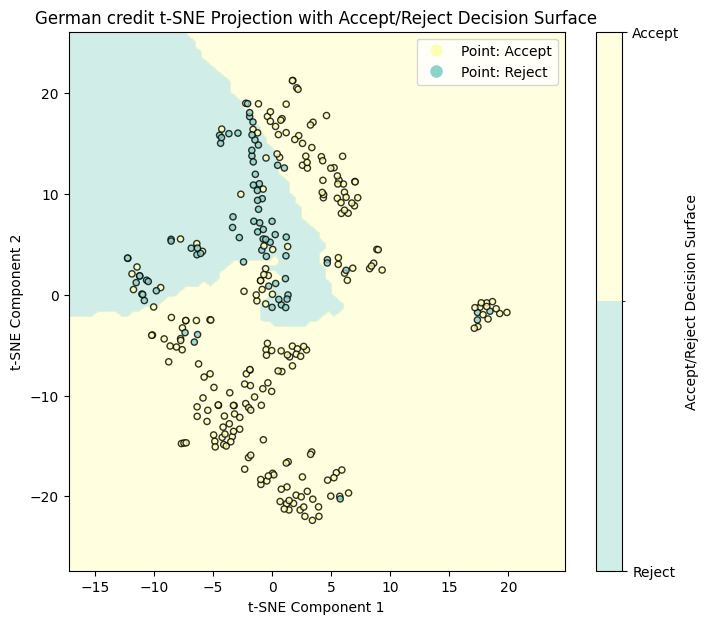

In [193]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.patches import Patch
from matplotlib.colors import BoundaryNorm
from sklearn.manifold import TSNE

# Stack all original instances into a matrix (all features)
X_full = np.array([cfs_[i]['original_instance'].values[0] for i in range(len(cfs_))])
accept_labels = np.array([cal_dist_dict[i]['accept'] for i in range(len(cfs_))])

# Project to 2D using t-SNE
#pca = PCA(n_components=2)
tsne = TSNE(n_components=2, random_state=0)
X_proj = tsne.fit_transform(X_full)

# Fit a simple classifier to the projected points for decision surface (e.g., KNN)
clf = KNeighborsClassifier(n_neighbors=10)
clf.fit(X_proj, accept_labels)

# Create a meshgrid for the 2D t-SNE space
h = .5  # step size in the mesh (t-SNE can be more spread out)
x_min, x_max = X_proj[:, 0].min() - 5, X_proj[:, 0].max() + 5
y_min, y_max = X_proj[:, 1].min() - 5, X_proj[:, 1].max() + 5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                    np.arange(y_min, y_max, h))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision surface
plt.figure(figsize=(8, 7))
levels = [0, 0.5, 1]  # boundaries for 0 and 1
norm = BoundaryNorm(levels, ncolors=2)
C = plt.contourf(xx, yy, Z, levels=levels, cmap=plt.cm.Set3, norm=norm, alpha=0.4)

# Add colorbar with only two ticks (0 and 1)
cbar = plt.colorbar(C, ticks=[0, 1])
cbar.ax.set_yticklabels(['Reject', 'Accept'])
cbar.set_label('Accept/Reject Decision Surface')

# C = plt.contourf(xx, yy, Z, 
#             #cmap='viridis',
#             #colors=['lightblue', 'lightcoral'],
#             cmap=plt.cm.Set3, 
#             alpha=0.4
#             )
# plt.colorbar(C, ticks=[0, 1], boundaries=[0,1],
#             label='Accept/Reject Decision Surface')

# Plot points colored by accept
surface_colors = [plt.cm.Set3(0), plt.cm.Set3(1)]
colors = [surface_colors[a] for a in accept_labels]
#colors = ['tab:blue' if a else 'tab:orange' for a in accept_labels]
plt.scatter(X_proj[:, 0], X_proj[:, 1], c=colors, edgecolor='k', alpha=0.8, s=20)

plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('German credit t-SNE Projection with Accept/Reject Decision Surface')

# Custom legend for surface and points
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Point: Accept', markerfacecolor=surface_colors[1], markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Point: Reject', markerfacecolor=surface_colors[0], markersize=10)
]
plt.legend(handles=legend_elements)
plt.show()

In [434]:
yy.shape

(108, 85)

## Add a test instance + its counterfactual

In [194]:
# rejected instaces
rej_idx = [i for i in test_dist_dict if (test_dist_dict[i]['accept']==0) and (len(test_dist_dict[i]['best_cf'])>0)]
acc_idx = [i for i in test_dist_dict if (test_dist_dict[i]['accept']==1) and (len(test_dist_dict[i]['best_cf'])>0)]
print(len(rej_idx), len(acc_idx))

122 378


### Matplotlib

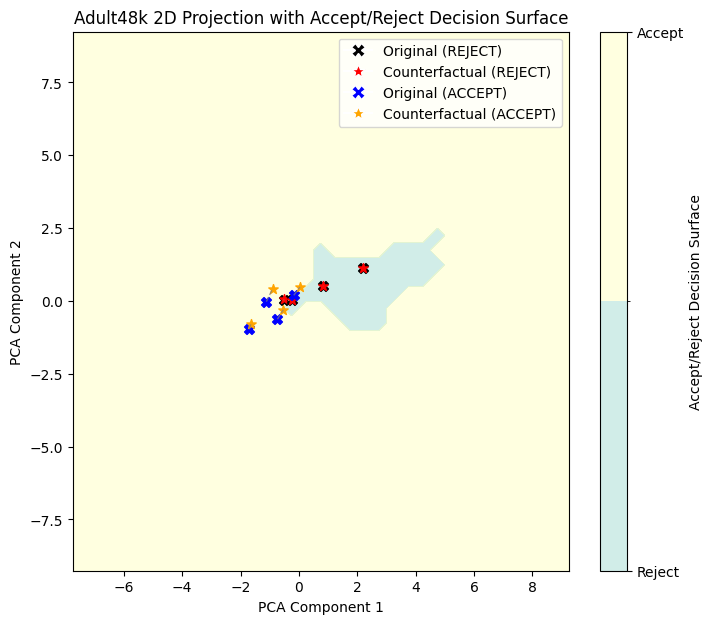

In [159]:
# Stack all original instances into a matrix (all features)
X_full = np.array([cfs_[i]['original_instance'].values[0] for i in range(len(cfs_))])
X_full_test = np.array([cfs_test[i]['original_instance'].values[0] for i in range(len(cfs_test))])
accept_labels = np.array([cal_dist_dict[i]['accept'] for i in range(len(cfs_))])
accept_labels_test = np.array([test_dist_dict[i]['accept'] for i in range(len(cfs_test))])
n_features = 12 if dataset == 'adult48k' else 20

# Project to 2D using t-SNE
#tsne = TSNE(n_components=2, random_state=0)
pca = PCA(n_components=2)
pca.fit(X_full)
X_proj = pca.transform(X_full)
X_proj_test = pca.transform(X_full_test)

# Fit a simple classifier to the projected points for decision surface (e.g., KNN)
clf = KNeighborsClassifier(n_neighbors=10)
clf.fit(X_proj, accept_labels)

# Create a meshgrid for the 2D t-SNE space
h = .5  # step size in the mesh (t-SNE can be more spread out)
x_min, x_max = min(X_proj[:, 0].min(), X_proj_test[:, 0].min()) - 5, max(X_proj[:, 0].max(), X_proj_test[:, 0].max()) + 5
y_min, y_max = min(X_proj[:, 1].min(), X_proj_test[:, 1].min()) - 5, max(X_proj[:, 1].max(), X_proj_test[:, 1].max()) + 5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                    np.arange(y_min, y_max, h))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision surface
plt.figure(figsize=(8, 7))
levels = [0, 0.5, 1]  # boundaries for 0 and 1
norm = BoundaryNorm(levels, ncolors=2)
C = plt.contourf(xx, yy, Z, levels=levels, cmap=plt.cm.Set3, norm=norm, alpha=0.4)

# Add colorbar with only two ticks (0 and 1)
cbar = plt.colorbar(C, ticks=[0, 1])
cbar.ax.set_yticklabels(['Reject', 'Accept'])
cbar.set_label('Accept/Reject Decision Surface')


# Plot points colored by accept
surface_colors = [plt.cm.Set3(0), plt.cm.Set3(1)]
colors_test = [surface_colors[a] for a in accept_labels_test]
colors = [surface_colors[a] for a in accept_labels]
#colors = ['tab:blue' if a else 'tab:orange' for a in accept_labels]
#plt.scatter(X_proj_test[:, 0], X_proj_test[:, 1], c=colors_test, alpha=1, s=20, marker='o')
#plt.scatter(X_proj[:, 0], X_proj[:, 1], c=colors, alpha=1, s=20, marker='x')

idx_to_plot = rej_idx[1:5]
for idx in idx_to_plot:
    #n_features = cfs_test[idx]['counterfactuals'].shape[1]-1
    x_original = cfs_test[idx]['original_instance'].values[0]
    x_cf = cfs_test[idx]['counterfactuals'].iloc[test_dist_dict[idx]['best_cf']].values[0][:n_features]
    
    x_original_2d = pca.transform(x_original.reshape(1, -1))
    x_cf_2d = pca.transform(x_cf.reshape(1, -1))
    
    plt.scatter(x_original_2d[0, 0], x_original_2d[0, 1], marker='X', color='black', s=50, label='Original')
    plt.scatter(x_cf_2d[0, 0], x_cf_2d[0, 1], marker='*', color='red', s=50, label='Counterfactual')
    plt.plot([x_original_2d[0, 0], x_cf_2d[0, 0]], [x_original_2d[0, 1], x_cf_2d[0, 1]], 
            color='gray', linestyle='--', linewidth=1, alpha=0.7)

idx_to_plot = acc_idx[1:5]
for idx in idx_to_plot:
    #n_features = cfs_test[idx]['counterfactuals'].shape[1]-1
    x_original = cfs_test[idx]['original_instance'].values[0]
    x_cf = cfs_test[idx]['counterfactuals'].iloc[test_dist_dict[idx]['best_cf']].values[0][:n_features]
    
    x_original_2d = pca.transform(x_original.reshape(1, -1))
    x_cf_2d = pca.transform(x_cf.reshape(1, -1))
    
    plt.scatter(x_original_2d[0, 0], x_original_2d[0, 1], marker='X', color='blue', s=50, label='Original')
    plt.scatter(x_cf_2d[0, 0], x_cf_2d[0, 1], marker='*', color='orange', s=50, label='Counterfactual')
    plt.plot([x_original_2d[0, 0], x_cf_2d[0, 0]], [x_original_2d[0, 1], x_cf_2d[0, 1]], 
            color='gray', linestyle='--', linewidth=1, alpha=0.7)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Adult48k 2D Projection with Accept/Reject Decision Surface')

# Custom legend for surface and points
legend_elements = [
    plt.Line2D([0], [0], marker='X', color='w', label='Original (REJECT)', markerfacecolor='black', markersize=10),
    plt.Line2D([0], [0], marker='*', color='w', label='Counterfactual (REJECT)', markerfacecolor='red', markersize=10),
    plt.Line2D([0], [0], marker='X', color='w', label='Original (ACCEPT)', markerfacecolor='blue', markersize=10),
    plt.Line2D([0], [0], marker='*', color='w', label='Counterfactual (ACCEPT)', markerfacecolor='orange', markersize=10)
]
plt.legend(handles=legend_elements)
# plt.xlim(-2, 3)
# plt.ylim(-2, 3)
plt.show()

### Plotly

In [195]:
import plotly.graph_objects as go
import plotly.express as px

# Project to 2D using PCA (already done)
# X_proj, X_proj_test, accept_labels, accept_labels_test, rej_idx, acc_idx, cfs_test, test_dist_dict, n_features

# Decision surface grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z_flat = Z.ravel()

# Plot decision surface as a heatmap
fig = go.Figure()

# Add decision surface
fig.add_trace(go.Heatmap(
    x=xx[0], y=yy[:,0], z=Z,
    colorscale=[[0, 'red'],
                [0.5, 'red'], 
                [0.5, 'green'],
                [1, 'green']],
    showscale=True,
    name='Accept/reject decision surface',
    colorbar=dict(
        tickvals=[0, 1],
        ticktext=['Reject', 'Accept'],
        title='Decision'
    ),
    opacity=0.4,
    zmin=0, zmax=1
))

x_original_2d_list = []
x_cf_2d_list = []
for idx in rej_idx[1:5]:
    x_original = cfs_test[idx]['original_instance'].values[0]
    x_cf = cfs_test[idx]['counterfactuals'].iloc[test_dist_dict[idx]['best_cf']].values[0][:n_features]
    x_original_2d = pca.transform(x_original.reshape(1, -1))[0]
    x_cf_2d = pca.transform(x_cf.reshape(1, -1))[0]
    x_original_2d_list.append(x_original_2d)
    x_cf_2d_list.append(x_cf_2d)

fig.add_trace(go.Scatter(
        x=[x[0] for x in x_original_2d_list],
        y=[x[1] for x in x_original_2d_list],
        mode='markers',
        marker=dict(symbol='x', color='black', size=12),
        line=dict(color='gray', dash='dash'),
        name='Original (REJECT)',
        showlegend=True,
        hovertext='REJECT (original)',
        hoverinfo='text'
    ))  
fig.add_trace(go.Scatter(
        x=[x[0] for x in x_cf_2d_list],
        y=[x[1] for x in x_cf_2d_list],
        mode='markers',
        marker=dict(symbol='star', color='red', size=14),
        name='Counterfactual (REJECT)',
        showlegend=True,
        hovertext='REJECT (counterfactual)',
        hoverinfo='text'
    )) 
for x, y in zip(x_original_2d_list, x_cf_2d_list):
    fig.add_trace(go.Scatter(
        x = [x[0], y[0]],
        y = [x[1], y[1]],
        mode='lines',
        line=dict(color='gray', dash='dash'),
        showlegend=False
    ))

x_original_2d_list = []
x_cf_2d_list = []
for idx in acc_idx[1:5]:
    x_original = cfs_test[idx]['original_instance'].values[0]
    x_cf = cfs_test[idx]['counterfactuals'].iloc[test_dist_dict[idx]['best_cf']].values[0][:n_features]
    x_original_2d = pca.transform(x_original.reshape(1, -1))[0]
    x_cf_2d = pca.transform(x_cf.reshape(1, -1))[0]
    x_original_2d_list.append(x_original_2d)
    x_cf_2d_list.append(x_cf_2d)
fig.add_trace(go.Scatter(
        x=[x[0] for x in x_original_2d_list],
        y=[x[1] for x in x_original_2d_list],
        mode='markers',
        marker=dict(symbol='x', color='blue', size=12),
        line=dict(color='gray', dash='dash'),
        name='Original (ACCEPT)',
        showlegend=True,
        hovertext='ACCEPT (original)',
        hoverinfo='text'
    ))  
fig.add_trace(go.Scatter(
        x=[x[0] for x in x_cf_2d_list],
        y=[x[1] for x in x_cf_2d_list],
        mode='markers',
        marker=dict(symbol='star', color='orange', size=14),
        name='Counterfactual (ACCEPT)',
        showlegend=True,
        hovertext='ACCEPT (counterfactual)',
        hoverinfo='text'
    )) 
for x, y in zip(x_original_2d_list, x_cf_2d_list):
    fig.add_trace(go.Scatter(
        x = [x[0], y[0]],
        y = [x[1], y[1]],
        mode='lines',
        line=dict(color='gray', dash='dash'),
        showlegend=False
    ))

# fig.add_trace(go.Scatter(
#         x=[x_original_2d[0], x_cf_2d[0]],
#         y=[x_original_2d[1], x_cf_2d[1]],
#         mode='lines',
#         line=dict(color='gray', dash='dash'),
#         #marker=dict(symbol='star', color='orange', size=14),
#         #name='Counterfactual (ACCEPT)',
#         showlegend=False
#     ))

fig.update_layout(
    title='Adult48k 2D Projection with Accept/Reject Decision Surface (Plotly)',
    xaxis_title='PCA Component 1',
    yaxis_title='PCA Component 2',
    legend=dict(itemsizing='constant'),
    width=900,
    height=700,
    xaxis=dict(range=[-1.5, 1.5]),
    yaxis=dict(range=[-1, 1.5])
)

fig.show()

## Local explanations

In [196]:
test_dist_dict[rej_idx[0]].keys()

dict_keys(['best_cf', 'min_d', 'bb_is_correct', 'tau', 'accept'])

In [ ]:
idx = rej_idx[0]

x_original = cfs_test[idx]['original_instance'].values[0]
x_input = {k:v for k, v in make_sample_human_readable(x_original).items() if not (k.endswith('_raw') or k.endswith('_probability') or k.startswith('employment'))}

x_cf = cfs_test[idx]['counterfactuals'].iloc[test_dist_dict[idx]['best_cf']].values[0][:n_features]
x_cf_input = {k:v for k, v in make_sample_human_readable(x_cf).items() if not (k.endswith('_raw') or k.endswith('_probability') or k.startswith('employment'))}

min_d = test_dist_dict[idx]['min_d']

y_true = cfs_test[idx]['true_class'].values[0]
if test_dist_dict[idx]['bb_is_correct']==True:
    y = y_true
else:
    y = 1 - y_true  # if the BB is not correct, we flip the label


In [342]:
def get_diff_features(idx):
    
    x_original = cfs_test[idx]['original_instance'].values[0]
    x_input = {k:v for k, v in make_sample_human_readable(x_original).items() if not (k.endswith('_raw') or k.endswith('_probability') or k.startswith('employment'))}

    x_cf = cfs_test[idx]['counterfactuals'].iloc[test_dist_dict[idx]['best_cf']].values[0][:n_features]
    x_cf_input = {k:v for k, v in make_sample_human_readable(x_cf).items() if not (k.endswith('_raw') or k.endswith('_probability') or k.startswith('employment'))}

    min_d = test_dist_dict[idx]['min_d']

    y_true = cfs_test[idx]['true_class'].values[0]
    if test_dist_dict[idx]['bb_is_correct']==True:
        y_bb = y_true
    else:
        y_bb = 1 - y_true  # if the BB is not correct, we flip the label
    
    y_cf = 1-y_bb

    keys = list(x_input.keys())

    # first get the features that are the same and different
    same = []
    diff = []
    hover_text = [f'Minimal changes to flip the label from {adult_class_encoding[y_bb]} to {adult_class_encoding[y_cf]}:']

    for k in keys:
        v1 = x_input[k]
        v2 = x_cf_input[k]
        if v1 == v2:
            same.append(k)
        else:
            diff.append(k)
    
    for k in diff:
        v1 = x_input[k]
        v2 = x_cf_input[k]
        hover_text.append(f"{k}: {v1} --> {v2}")
    hover_text = '\n'.join(hover_text)
    return hover_text

In [556]:
adult_class_encoding = {
    0: '<=50K',
    1: '>50K'
}

def print_explanation(idx, font_size=20):
    
    x_original = cfs_test[idx]['original_instance'].values[0]
    x = {k:v for k, v in make_sample_human_readable(x_original).items() if not (k.endswith('_raw') or k.endswith('_probability') or k.startswith('employment'))}

    x_cf = cfs_test[idx]['counterfactuals'].iloc[test_dist_dict[idx]['best_cf']].values[0][:n_features]
    c = {k:v for k, v in make_sample_human_readable(x_cf).items() if not (k.endswith('_raw') or k.endswith('_probability') or k.startswith('employment'))}

    min_d = test_dist_dict[idx]['min_d']
    y_true = cfs_test[idx]['true_class'].values[0]
    if test_dist_dict[idx]['bb_is_correct']==True:
        y = y_true
    else:
        y = 1 - y_true  # if the BB is not correct, we flip the label

    keys = list(x.keys())
    demographics = ['age', 'education', 'sex', 'marital-status', 'relationship', 'race', 'native-country']
    work_info = ['workclass', 'occupation', 'hours-per-week']
    financial_info = ['capital-gain', 'capital-loss']
    
    # first get the features that are the same and different
    same = []
    diff = []

    for k in keys:
        v1 = x[k]
        v2 = c[k]
        if v1 == v2:
            same.append(k)
        else:
            diff.append(k)

    html = []
    # html.append("<p>This instance was rejected because it falls inside the uncertainty zone of the AI model.</p>")
    #html.append(f"<p style='font-size: {font_size}px'>While the ML model would have suggested the output <b>{adult_class_encoding[y]}</b>, the opposite prediction would have been obtained with a near identical input:</p>")
    html.append(f"<p style='font-size: {font_size}px'>Although the model leans toward <b>{adult_class_encoding[y]}</b>, an almost identical case would produce the opposite prediction, indicating high uncertainty:</p>")
    def section_list(features, values, changed=False):
        items = []
        for f in features:
            if f in values:
                fname = f.replace('-', ' ').capitalize()
                if changed:
                    items.append(f"<li><b>{fname}</b>: {x[f]} &rarr; {c[f]}</li>")
                else:
                    items.append(f"<li><b>{fname}</b>: {x[f]}</li>")
        return ''.join(items)

    #html = []
    #html.append(f"<p style='font-size: 18px'>While the ML model would have suggested the output <b>{adult_class_encoding[y]}</b>, the opposite prediction would have been obtained with a near identical input:</p>")
    html.append("""
    <div style="display: flex; gap: 1px; font-size: {font_size}px;">
      <div style="flex: 1;">
        <b>IDENTICAL FEATURES</b>
        <ul style="list-style-type:none;padding-left:-30;">
          <li style="margin-top: 18px;"><b>Demographic information</b>
            <ul>
              {dem_same}
            </ul>
          </li>
          <li style="margin-top: 18px;"><b>Work-related information</b>
            <ul>
              {work_same}
            </ul>
          </li>
          <li style="margin-top: 18px;"><b>Financial information</b>
            <ul>
              {fin_same}
            </ul>
          </li>
        </ul>
      </div>
      <div style="flex: 1;color: firebrick;">
        <b>MINIMAL CHANGES TO FLIP THE PREDICTION TO {opp_class}: </b>
        <ul style="list-style-type:none;padding-left:0;">
          <li style="margin-top: 18px;"><b>Demographic information</b>
            <ul>
              {dem_diff}
            </ul>
          </li>
          <li style="margin-top: 18px;"><b>Work-related information</b>
            <ul>
              {work_diff}
            </ul>
          </li>
          <li style="margin-top: 18px;"><b>Financial information</b>
            <ul>
              {fin_diff}
            </ul>
          </li>
        </ul>
      </div>
    </div>
    """.format(
        font_size=font_size,
        dem_same=section_list(demographics, same),
        work_same=section_list(work_info, same),
        fin_same=section_list(financial_info, same),
        dem_diff=section_list(demographics, diff, changed=True),
        work_diff=section_list(work_info, diff, changed=True),
        fin_diff=section_list(financial_info, diff, changed=True),
        opp_class=adult_class_encoding[1 - y]
    ))
    from IPython.display import display, HTML
    display(HTML(''.join(html)))
    return html

In [557]:
e  = print_explanation(rej_idx[0], 23)

In [ ]:
col_map_adult = {}
for i in enumerate(cfs_[0]['original_instance'].columns):
    col_map_adult[i[0]] = i[1]
col_map_adult

{0: 'age',
 1: 'capital-gain',
 2: 'capital-loss',
 3: 'hours-per-week',
 4: 'workclass',
 5: 'education',
 6: 'marital-status',
 7: 'occupation',
 8: 'relationship',
 9: 'race',
 10: 'sex',
 11: 'native-country'}

In [ ]:
def plot_instance_distance_bar(idx, cal_dist_dict, test_dist_dict):
    
    # Compute max distance and tau
    all_distances = [cal_dist_dict[i]['min_d'] for i in range(len(cal_dist_dict))]
    max_dist = sorted(all_distances)[-2]
    tau = cal_dist_dict[0]['tau'] if 'tau' in cal_dist_dict[0] else None

    # Pastel colors
    pastel_red = "#FFB3AB"
    pastel_green = "#B6E2A1"
    pastel_blue = "#3465A4"

    fig = go.Figure()

    # Red segment (0 to tau)
    fig.add_trace(go.Bar(
        x=[tau/2],
        y=[1],
        width=[tau],
        marker=dict(color=pastel_red),
        name='REJECT: Below tau',
        hoverinfo='skip',
        showlegend=False,
        orientation='v'
    ))

    # Green segment (tau to max)
    fig.add_trace(go.Bar(
        x=[(tau + max_dist)/2],
        y=[1],
        width=[max_dist - tau],
        marker=dict(color=pastel_green),
        name='ACCEPT: Above tau',
        hoverinfo='skip',
        showlegend=False,
        orientation='v'
    ))

    # Add a line for the test instance
    test_distance = test_dist_dict[idx]['min_d']
    gap = test_distance - tau
    rel_gap = gap / tau if tau != 0 else 0
    # Get diff features for hover text
    diff_text = get_diff_features(idx).replace('\n', '<br>* ')
    
    
    fig.add_shape(
        type="line",
        x0=test_distance, x1=test_distance,
        y0=0, y1=1,
        line=dict(color=pastel_blue, width=2),
        name='test_distance'
    )
    # Add a marker in the middle of the test instance line
    fig.add_trace(go.Scatter(
        x=[test_distance],
        y=[0.5],
        mode='markers',
        marker=dict(color=pastel_blue, size=14, symbol='circle'),
        name='Test instance',
        hovertemplate=(
            f"Distance: {test_distance:.3f}<br>"
            f"Relative gap to rejection threshold: {rel_gap:.2%}<br>"
            f"{diff_text}<extra></extra>"
        ),
        showlegend=False
    ))

    # Add a vertical line for tau
    fig.add_shape(
        type="line",
        x0=tau, x1=tau,
        y0=0, y1=1,
        line=dict(color="black", dash="dash"),
        name='tau'
    )

    # Add "REJECT" and "ACCEPT" text annotations above the bars
    fig.add_annotation(
        x=tau/2,
        y=1.35,
        text="REJECT<br>uncertainty zone",
        showarrow=False,
        font=dict(size=20, color="red")
    )
    fig.add_annotation(
        x=(tau + max_dist)/2,
        y=1.35,
        text="ACCEPT<br>safe prediction",
        showarrow=False,
        font=dict(size=20, color="green")
    )
    fig.update_layout(
        title="Instance-Counterfactual Distance Bar (Coverage=75%)",
        title_x=0.5,
        yaxis=dict(showticklabels=False, range=[0, 1.4]),
        xaxis=dict(
            range=[0, max_dist * 1.05],
            tickvals=[0, tau, test_distance, max_dist],
            ticktext=[
                "0",
                f"<b><span style='
                red'>&#964; = {tau:.4f}</span></b>",
                f"{test_distance:.4f}",
                f"{max_dist:.2f}"
            ],
            showgrid=False
        ),
        showlegend=False,
        bargap=0,
        height=300,
        plot_bgcolor='white'
    )

    #fig.show()
    
    return fig

# Usage:
# plot_instance_distance_bar(idx, cal_dist_dict, test_dist_dict)

In [390]:
plot_instance_distance_bar(idx, cal_dist_dict, test_dist_dict)

In [ ]:
print_explanation(x_input, x_cf_input, y)

In [478]:
def plot_instance_distance_bar_v(idx, cal_dist_dict, test_dist_dict, max_dist=None):

    if max_dist is None:
        # Compute max distance and tau
        all_distances = [cal_dist_dict[i]['min_d'] for i in range(len(cal_dist_dict))]
        max_dist = sorted(all_distances)[-2]
    
    tau = cal_dist_dict[0]['tau'] if 'tau' in cal_dist_dict[0] else None

    # Pastel colors
    pastel_red = "#FFB3AB"
    pastel_green = "#B6E2A1"
    pastel_blue = "#3465A4"

    fig = go.Figure()

    # Red segment (0 to tau) - vertical bar
    fig.add_trace(go.Bar(
        y=[tau/2],
        x=[1],
        orientation='h',
        width=[tau],
        marker=dict(color=pastel_red),
        name='REJECT: Below tau',
        hoverinfo='skip',
        showlegend=False,
    ))

    # Green segment (tau to max) - vertical bar
    fig.add_trace(go.Bar(
        y=[(tau + max_dist)/2],
        x=[1],
        orientation='h',
        width=[max_dist - tau],
        marker=dict(color=pastel_green),
        name='ACCEPT: Above tau',
        hoverinfo='skip',
        showlegend=False,
    ))

    # Add a line for the test instance (vertical)
    test_distance = test_dist_dict[idx]['min_d']
    gap = test_distance - tau
    rel_gap = gap / tau if tau != 0 else 0

    # Use diff_idx for hover text if provided, else use idx
    #cf_idx = cf_idx if cf_idx is not None else idx
    diff_text = get_diff_features(idx).replace('\n', '<br>* ')

    fig.add_shape(
        type="line",
        y0=test_distance, y1=test_distance,
        x0=0, x1=1,
        line=dict(color=pastel_blue, width=2),
        name='test_distance'
    )
    # Add a marker in the middle of the test instance line
    fig.add_trace(go.Scatter(
        y=[test_distance],
        x=[0.5],
        mode='markers',
        marker=dict(color=pastel_blue, size=14, symbol='circle'),
        name='Test instance',
        hovertemplate=(
            f"<b>Distance:</b> {test_distance:.3f}<br>"
            f"<b>Relative gap to the rejection threshold:</b> {rel_gap:.2%}<br>"
            f"<span style='text-align:left'>{diff_text}</span><extra></extra>"
        ),
        showlegend=False
    ))

    # Add a horizontal line for tau
    fig.add_shape(
        type="line",
        y0=tau, y1=tau,
        x0=0, x1=1,
        line=dict(color="black", dash="dash"),
        name='tau'
    )

# Move "REJECT" and "ACCEPT" text annotations to the left of the bar (left of ticks)
    fig.add_annotation(
        y=tau/2,
        x=-0.2,  # further left
        text="REJECT<br>uncertainty zone",
        showarrow=False,
        font=dict(size=18, color="red"),
        xanchor="right",
        yanchor="middle"
    )
    fig.add_annotation(
        y=(tau + max_dist)/2,
        x=-0.2,  # further left
        text="ACCEPT<br>safe AI prediction",
        showarrow=False,
        font=dict(size=18, color="green"),
        xanchor="right",
        yanchor="middle"
    )
    fig.update_layout(
        title=f"Instance-Counterfactual Distance Bar<br>Coverage=75%",
        title_x=0.5,
        xaxis=dict(
            showticklabels=False,
            range=[-1.5, 1],  # expand left margin for annotation
            showgrid=False
        ),
        yaxis=dict(
            range=[0, max_dist * 1.05],
            tickvals=[0, tau, test_distance],
            ticktext=[
                "0",
                fr"<b><span style='color:red'>&#964; = {tau:.4f}</span></b>",
                f"{test_distance:.4f}"
                #f"{max_dist:.2f}"
            ],
            showgrid=False,
            ticks="outside",
            tickson="boundaries",
            side="right",
            #ticklen=3,
            tickfont=dict(size=15),
            ticklabelposition="outside right"
        ),
        margin=dict(l=30, r=30, t=40, b=40),  # increase left margin for ticks and annotation
        showlegend=False,
        bargap=0,
        height=500,
        width=550,
        plot_bgcolor='white'
    )

    return fig

# Usage:
plot_instance_distance_bar_v(good_idxs[0], cal_dist_dict, test_dist_dict, max_dist=0.5)

### Select instance to plot

In [334]:
col_map_adult_by_name = {v:k for k, v in col_map_adult.items()}

def get_cf_differing_1f(rej_idx, feature_name):
    differing_1f = []
    feature_index = col_map_adult_by_name[feature_name]
    for idx in rej_idx:
        x_original = cfs_test[idx]['original_instance'].values[0]
        x_cf = cfs_test[idx]['counterfactuals'].iloc[test_dist_dict[idx]['best_cf']].values[0][:n_features]
        
        # Check if only the feature at feature_index differs
        if np.sum(x_original != x_cf) == 1 and x_original[feature_index] != x_cf[feature_index]:
            differing_1f.append(idx)
    
    return differing_1f

def get_cf_differing_nf(rej_idx, feature_names):
    differing_nf = []
    feature_indices = [col_map_adult_by_name[name] for name in feature_names]
    for idx in rej_idx:
        x_original = cfs_test[idx]['original_instance'].values[0]
        x_cf = cfs_test[idx]['counterfactuals'].iloc[test_dist_dict[idx]['best_cf']].values[0][:n_features]
        diff_indices = np.where(x_original != x_cf)[0]
        
        # Only the specified features differ (at least one, but not others)
        if len(diff_indices) > 0 and all(i in feature_indices for i in diff_indices):
            differing_nf.append(idx)

    return differing_nf

In [338]:
good_idxs = get_cf_differing_nf(rej_idx, ['sex', 'race', 'education'])

In [475]:
plot_instance_distance_bar(good_idxs[0], cal_dist_dict, test_dist_dict)

In [508]:
plot_instance_distance_bar_v(good_idxs[10], cal_dist_dict, test_dist_dict, max_dist=0.5)

In [564]:
print_explanation(good_idxs[10], 34)

["<p style='font-size: 34px'>Although the model leans toward <b><=50K</b>, an almost identical case would produce the opposite prediction, indicating high uncertainty:</p>",
 '\n    <div style="display: flex; gap: 1px; font-size: 34px;">\n      <div style="flex: 1;">\n        <b>IDENTICAL FEATURES</b>\n        <ul style="list-style-type:none;padding-left:-30;">\n          <li style="margin-top: 18px;"><b>Demographic information</b>\n            <ul>\n              <li><b>Age</b>: 70 years old</li><li><b>Education</b>: High School</li><li><b>Sex</b>: Male</li><li><b>Marital status</b>: Married-civ-spouse</li><li><b>Relationship</b>: Husband</li><li><b>Native country</b>: United-States</li>\n            </ul>\n          </li>\n          <li style="margin-top: 18px;"><b>Work-related information</b>\n            <ul>\n              <li><b>Workclass</b>: Federal-gov</li><li><b>Occupation</b>: Adm-clerical</li><li><b>Hours per week</b>: 40 hours/week</li>\n            </ul>\n          </li>\

In [175]:
# Denormalize numeric features
means = np.array([38.643585, 1079.0676, 87.50231, 40.422382], dtype=np.float32)
stds = np.array([13.71037, 7451.9424, 403.00046, 12.391317], dtype=np.float32)

def denormalize(val):
    den = int(round(val * 13.71037) + 38.643585)
    return den

country_dict = {0.25670945157526254: ' ?',
 0.29596096535683447: ' Cambodia',
 0.3461538363070802: ' Canada',
 0.2950798931789342: ' China',
 0.047347385199526214: ' Columbia',
 0.24637675834941963: ' Cuba',
 0.04859107916476352: ' Dominican-Republic',
 0.1413703885882764: ' Ecuador',
 0.07096797268680777: ' El-Salvador',
 0.370075791414291: ' England',
 0.39526824068520733: ' France',
 0.2815533977049296: ' Germany',
 0.36066788369302705: ' Greece',
 0.03431919131249288: ' Guatemala',
 0.12048549321336761: ' Haiti',
 0.20814918021620007: ' Holand-Netherlands',
 0.1696408828467303: ' Honduras',
 0.25930173247485605: ' Hong',
 0.27562451930735055: ' Hungary',
 0.41059567611361025: ' India',
 0.3702306992159193: ' Iran',
 0.28833591282914844: ' Ireland',
 0.3237923285831285: ' Italy',
 0.14152743110161864: ' Jamaica',
 0.34774510976311024: ' Japan',
 0.15177966918238522: ' Laos',
 0.04942166140904311: ' Mexico',
 0.07051081116601206: ' Nicaragua',
 0.1268039075818783: ' Outlying-US(Guam-USVI-etc)',
 0.09748804848454774: ' Peru',
 0.2881355932202833: ' Philippines',
 0.19545624420661376: ' Poland',
 0.17964687348153752: ' Portugal',
 0.10869566202462137: ' Puerto-Rico',
 0.18866084554388723: ' Scotland',
 0.17391793608051587: ' South',
 0.39823419797998383: ' Taiwan',
 0.18619587461185555: ' Thailand',
 0.1288920062852573: ' Trinadad&Tobago',
 0.24397700310275597: ' United-States',
 0.08160984068441025: ' Vietnam',
 0.3016342387854267: ' Yugoslavia'}

adult_class_encoding = {
    0: '<=50K',
    1: '>50K'
}


In [499]:
denormalize(cfs_test[idx]['counterfactuals'].iloc[test_dist_dict[idx]['best_cf']].values[0][0])

55

In [176]:
for idx in native_country_diffs:
    o = cfs_test[idx]['original_instance'].values[0][11]
    c = cfs_test[idx]['counterfactuals'].iloc[test_dist_dict[idx]['best_cf']].values[0][:n_features][11]
    y_pred = rf.predict(cfs_test[idx]['original_instance'])[0]
    y_true = cfs_test[idx]['true_class'][0]
    if y_pred != y_true:
        print('The classifier is too uncertain to make a prediction. Indeed it would have made a mistake:')
        print('---BB prediction = ', adult_class_encoding[y_pred], ' instead of ', adult_class_encoding[y_true])
        print('a different prediction would have been obtained by only changing the native country of the person')
        print('from ', country_dict[o], ' to ', country_dict[min(country_dict.keys(), key=lambda k: abs(k - c))])
    else:
        print('Correct prediction')

Correct prediction
Correct prediction
Correct prediction
The classifier is too uncertain to make a prediction. Indeed it would have made a mistake:
---BB prediction =  <=50K  instead of  >50K
a different prediction would have been obtained by only changing the native country of the person
from   United-States  to   Cuba
Correct prediction
Correct prediction
The classifier is too uncertain to make a prediction. Indeed it would have made a mistake:
---BB prediction =  >50K  instead of  <=50K
a different prediction would have been obtained by only changing the native country of the person
from   ?  to   Holand-Netherlands
Correct prediction
Correct prediction
The classifier is too uncertain to make a prediction. Indeed it would have made a mistake:
---BB prediction =  <=50K  instead of  >50K
a different prediction would have been obtained by only changing the native country of the person
from   Puerto-Rico  to   Scotland
Correct prediction
Correct prediction
Correct prediction
The classif

In [443]:
# find the rejected instances that only change based on 9=race or 10=sex
diff_indices = np.where(x_original != x_cf)[0]
all(i in [9, 10] for i in diff_indices) and len(diff_indices) > 0

False

In [441]:
cfs_[0]['original_instance'].columns

Index(['age', 'capital-gain', 'capital-loss', 'hours-per-week', 'workclass',
       'education', 'marital-status', 'occupation', 'relationship', 'race',
       'sex', 'native-country'],
      dtype='object')

In [270]:
idx = 9
print(cfs_[idx]['original_instance'].values[0])
print(cfs_[idx]['counterfactuals'].iloc[cal_dist_dict[idx]['best_cf']].values[0][:12])
    

[-1.4327538  -0.14480354 -0.21712708 -2.05162859  0.21786704  0.17125497
  0.04547993  0.26798692  0.01464187  0.25398688  0.10925148  0.243977  ]
[-1.4327538   0.8212254  -0.21712708 -2.05162859  0.22738035  0.38167311
  0.1931138   0.41165092  0.26733442  0.25398688  0.17458785  0.36073188]


In [273]:
len(cfs_[9]['counterfactuals'])

674